# Best CW Project: All the Steps!1

In [1]:
%load_ext autoreload
%autoreload 2

# -----------------------------
# Astronomical / physical constants
# -----------------------------
c = 299792458.0  # speed of light [m/s]
Tsun = 4.9254909476412675e-06  # G*M_sun/c^3 [s]
kpc = 3.085677581491367e19  # kiloparsec [m]
Mpc = 3.085677581491367e22  # megaparsec [m]

# Reference time used to shift TOAs in CW residual evaluation.
# Shifting can improve numerical stability when times are large.
tref = 1e9  # [s]


# ------------------------------------------
# Example custom overlap reduction function(s)
# ------------------------------------------

import sys
sys.path.append('/data/taylor_group/Nima/ATLAS')
sys.path.append('../')
import numpy as np
import pickle
import random
import json
import os
from ATLAS.data import PTA_Data
from ATLAS.model_builder import ModelBuilder
from ATLAS.psd_functions import powerlaw, free_spectrum, gwb_free_spectrum, hd_orf, gt_orf, bin_orf
from functools import partial
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
import jax.random as jrandom
from ATLAS.samplers.canetoadracing import model_maker
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
from ATLAS.signals.deterministic.det_signals import cw_delay_evolve_float64
from ATLAS.signals.deterministic.base import JointDeterministic, Deterministic
from ATLAS.flows import Flow

import glob
from enterprise.pulsar import FeatherPulsar

# holodeck: population synthesis + GW calculations
from holodeck import sams, utils, hardening, host_relations, gravwaves
from holodeck.constants import YR, PC, GYR, MSOL
from joblib import Parallel, delayed

from tqdm_joblib import ParallelPbar
from joblib import delayed

from tqdm.auto import trange
from functools import partial

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import corner
hist_settings = dict(
    bins = 20,
    histtype = 'step', 
    lw = 3,
    density = True
)

plt.style.use('default')
def figsize(scale, wc = 1, hc = 1):
    fig_width_pt = 513.17 #469.755                  # Get this from LaTeX using \the\textwidth
    inches_per_pt = 1.0/72.27                       # Convert pt to inch
    golden_mean = (np.sqrt(5.0)-1.0)/2.0            # Aesthetic ratio (you could change this)
    fig_width = fig_width_pt*inches_per_pt*scale    # width in inches
    fig_height = fig_width*golden_mean              # height in inches
    fig_size = [wc * fig_width,hc * fig_height]
    return fig_size
plt.rcParams.update(plt.rcParamsDefault)

params = {#'backend': 'pdf',
        'axes.labelsize': 12,
        'lines.markersize': 4,
        'font.size': 10,
        'xtick.major.size':6,
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "xtick.major.top": True, 
        "xtick.minor.top": True,
        "ytick.minor.visible": True, 
        "ytick.major.right": True, 
        "ytick.minor.right": True,
        "ytick.direction": "in",
        "xtick.direction": "in",
        'xtick.minor.size':3,  
        'ytick.major.size':6,
        'ytick.minor.size':3, 
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'xtick.minor.width':0.5,
        'ytick.minor.width':0.5,
        'lines.markeredgewidth':1,
        'axes.linewidth':1.2,
        'legend.fontsize': 7,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'savefig.dpi':200,
        'path.simplify':True,
        'font.family': 'serif',
        'font.serif':'Times',
        # "text.usetex": True,
        #'text.latex.preamble': [r'\usepackage{amsmath}'],
        'text.usetex':False,
        'figure.figsize': figsize(0.5, 1, 1)}
plt.rcParams.update(params)
plt.rcParams['font.family'] = 'STIXGeneral'  # Closely matches Computer Modern
plt.rcParams['mathtext.fontset'] = 'stix'    # Use STIX for math

/panfs/accrepfs.vampire/home/laaln1/pandora/lib/python3.12/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
2026-08-26 14:07:42.816318: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787771263.092484 3638922 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787771263.172679 3638922 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787771264.146587 3638922 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same ta

In [2]:
def make_corner(chains, 
                colors, 
                labels = None, 
                legend_labels = None, 
                ranges = None,
                truths = None,
                save_path = None):
    
    levels = [1 - np.exp(-0.5), 1 - np.exp(-1.0), 1 - np.exp(-1.5)]

    s = int((chains[0].shape[-1])/2 * 1.5)
    plt.close()
    fig = plt.figure(figsize = figsize(0.5, s, s))
    for chain, color in zip(chains, colors):
        fig = corner.corner(
        chain,
        fig=fig,
        range = ranges,
        labels=labels,
        color=color,
        bins=20,
        hist_bin_factor=2,
        truths = truths,
        truth_color = 'k',
        data_kwargs={'ms': 3},
        hist_kwargs={'density': True, 'lw': 2},
        contour_kwargs={'linewidths': 2},
        density=True,
        plot_datapoints=False,
        show_titles = True,
        levels = levels
    )

    ndim = chain.shape[-1]
    # --- Legend, anchored to the first (top-left) subplot's actual position ---
    if legend_labels is not None:
        legend_handles = [
            Line2D([0], [0], color=color, lw=2, label=lg_lab)
            for lg_lab, color in zip(legend_labels, colors)
        ]

        # Grab the axes grid corner.corner produced, and get the first
        # (top-left, diagonal) panel's position in figure coordinates.
        axes = np.array(fig.axes).reshape((ndim, ndim))
        ax0 = axes[0, 0]
        pos = ax0.get_position()  # Bbox in figure-fraction coords

        fig.legend(
            handles=legend_handles,
            loc='lower left',                 # anchor point = legend's lower-left corner
            bbox_to_anchor=(pos.x1, pos.y1),  # placed at ax0's top-right corner
            bbox_transform=fig.transFigure,
            fontsize=12,
            frameon=True,
        )
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

## Use `holodeck` to generate 

In [ ]:
'''
This code uses holodeck to generate all the CW params you need for each source behind a realization of GWB
'''
# Layer 1: Astro Parameters

theta_master = np.load('/data/taylor_group/Nima/Astro/nimsim_lib_astro_more.npy', mmap_mode = 'r')
theta_master.shape
SAM_SHAPE = (100, 100, 100) #finer
PTA_DUR_yr = 634788327.9482832/(86400 * 365.25)
PTA_DUR = PTA_DUR_yr * YR
NUM_FREQS = 5
gwb_freq_bins = NUM_FREQS
Tspan = PTA_DUR
freqs = np.arange(1/Tspan, (gwb_freq_bins + .001)/Tspan, 1/Tspan)

masked_shape = (SAM_SHAPE[0] - 1, SAM_SHAPE[1] - 1, SAM_SHAPE[2] - 1, NUM_FREQS)
n_draws_poisson = int(1e4)

def filter_and_cut(arr, first_dim_to_keep, last_dim = 1):
    return arr.reshape(np.prod(masked_shape[:first_dim_to_keep]), 1)

def init_sam(sam_shape, params):
    """Initialize a holodeck `Semi-Analytic Model` (SAM) from a parameter dictionary.

    This assembles the ingredients (GSMF, pair fraction, merger time, BH–host relation, etc.)
    into a single SAM object used to draw SMBHB populations.

    Parameters
    ----------
    sam_shape : tuple
        Broadcast shape for parameters (e.g., for vectorized sweeps).
    params : dict
        Dictionary of SAM hyper-parameters.

    Returns
    -------
    holodeck.sams.SemiAnalyticModel
        Configured SAM instance."""
    gsmf = sams.GSMF_Schechter(
        phi0=params['gsmf_phi0_log10'],
        phiz=params['gsmf_phiz'],
        mchar0_log10=params['gsmf_mchar0_log10'],
        mcharz=params['gsmf_mcharz'],
        alpha0=params['gsmf_alpha0'],
        alphaz=params['gsmf_alphaz'],
    )
    gpf = sams.GPF_Power_Law(
        frac_norm_allq=params['gpf_frac_norm_allq'],
        malpha=params['gpf_malpha'],
        qgamma=params['gpf_qgamma'],
        zbeta=params['gpf_zbeta'],
        max_frac=params['gpf_max_frac'],
    )
    gmt = sams.GMT_Power_Law(
        time_norm=params['gmt_norm']*GYR,
        malpha=params['gmt_malpha'],
        qgamma=params['gmt_qgamma'],
        zbeta=params['gmt_zbeta'],
    )
    mmbulge = host_relations.MMBulge_KH2013(
        mamp_log10=params['mmb_mamp_log10'],
        mplaw=params['mmb_plaw'],
        scatter_dex=params['mmb_scatter_dex'],
    )

    sam = sams.Semi_Analytic_Model(
        gsmf=gsmf, gpf=gpf, gmt=gmt, mmbulge=mmbulge,
        shape=sam_shape,
        mtot = (1e7 * MSOL, 1e11 * MSOL, 91),
        mrat = (1e-1, 1.0, 81),
        redz = (1e-3, 3.0, 101),
            )
    return sam

def init_hard(sam, params):
    hard = hardening.Fixed_Time_2PL_SAM(
        sam,
        params['hard_time']*GYR,
        sepa_init=params['hard_sepa_init']*PC,
        rchar=params['hard_rchar']*PC,
        gamma_inner=params['hard_gamma_inner'],
        gamma_outer=params['hard_gamma_outer'],
    )
    return hard
params = dict(
    hard_time=3.0,          #This needs to be varied
    hard_sepa_init=1e4,     
    hard_rchar=100.0,       
    hard_gamma_inner=-1.0,  #This needs to be varied
    hard_gamma_outer=+2.5,

    gsmf_phi0_log10=-2.77,  #This needs to be varied
    gsmf_phiz=-0.6,
    gsmf_mchar0_log10=11.24, #This needs to be varied
    gsmf_mcharz=0.11,
    gsmf_alpha0=-1.21,
    gsmf_alphaz=-0.03,

    gpf_frac_norm_allq=0.025,
    gpf_malpha=0.0,
    gpf_qgamma=0.0,
    gpf_zbeta=1.0,
    gpf_max_frac=1.0,

    gmt_norm=0.5,           
    gmt_malpha=0.0,
    gmt_qgamma=-1.0,      
    gmt_zbeta=-0.5,

    mmb_mamp_log10=8.69, #This needs to be varied
    mmb_plaw=1.10,          
    mmb_scatter_dex=0.3, #This needs to be varied
)

def doit(rr):
    theta = theta_master[rr]
    params['hard_time'] = theta[0]
    params['gsmf_phi0_log10'] = theta[1]
    params['gsmf_mchar0_log10'] = theta[2]
    params['mmb_mamp_log10'] = theta[3]
    params['mmb_scatter_dex'] = theta[4]
    params['hard_gamma_inner'] = theta[5]
    sam = init_sam(sam_shape = SAM_SHAPE, params = params)
    hard = init_hard(sam, params)
    fobs_gw_cents, fobs_gw_edges = utils.pta_freqs(PTA_DUR, NUM_FREQS)
    edges, redz_final, lambda_poisson, realize = sam.gwb_new_nima(fobs_gw_edges, hard=hard, realize=1)
    ans = np.broadcast_arrays(*gravwaves.strain_amp_from_bin_edges_redz(edges, redz_final)) 

    expected = filter_and_cut(lambda_poisson, 4)
    num_sources = np.array(np.random.poisson(expected))

    dc = np.log10(filter_and_cut(ans[1], 4)/(Mpc * 100))
    mask2 = np.logical_and(np.isfinite(dc), dc > 0)

    log10_freq = np.log10(filter_and_cut(ans[2], 4))
    mask3 = np.isfinite(log10_freq)

    mchirp = (np.log10(filter_and_cut(ans[0], 4)) + np.log10(5.029) - 34)
    mask4 = np.isfinite(mchirp)

    mask = mask2 & mask3 & mask4

    num_sources = num_sources[mask]
    mchirp = mchirp[mask]
    log10_freq = log10_freq[mask]
    dc = dc[mask]
    expected = expected[mask]
    # extended_source_draw = np.random.poisson(expected, size = (int(1e3), expected.shape[0]))

    sdir = '/data/taylor_group/Nima/Astro/data_good_range_100_res/'
    os.makedirs(sdir, exist_ok = True)
    np.save(sdir + f'/from_holo_{rr}_data.npy', [mchirp, dc, log10_freq, num_sources, expected])
    # np.save(sdir + f'/from_holo_{rr}_source_draws.npy', extended_source_draw)

# Parallel(n_jobs=34)(delayed(doit)(_) for _ in range(len(theta_master)))
# doit(0)

ParallelPbar("Generating Holodeck Data")(n_jobs=-1)(
delayed(doit)(_) for _ in range(len(theta_master))
)

## CW Ranking and Flow Training

In [ ]:
n_p_draws = int(1e3) #Poisson Draws
n_cw = 20 #Number of CWs to extract

In [3]:
astro_sample_index = 0
holo_data = jnp.load(f'/data/taylor_group/Nima/Astro/data_good_range_100_res/from_holo_{astro_sample_index}_data.npy', 
                    mmap_mode = 'r')
holo_data.shape

(5, 1054462)

In [4]:
num_copies = np.random.poisson(holo_data[-1], size = (n_p_draws, holo_data.shape[1]))
num_copies.shape

(1000, 1054462)

In [5]:
from holodeck.constants import NWTG, SPLC, MSOL, MPC

def hs_from_saved(mchirp_log10_msun, dc_log10_100mpc, log10_freq_orb_rest):
    Mc = (10**mchirp_log10_msun) * MSOL                 # -> grams
    Dc = (10**dc_log10_100mpc) * 100 * MPC               # -> cm
    fr = 10**log10_freq_orb_rest                         # -> Hz, rest-frame orbital
    hs = 8/np.sqrt(10) * (NWTG*Mc)**(5/3) * (2*np.pi*fr)**(2/3) / (SPLC**4 * Dc)
    return hs

In [6]:
hs = hs_from_saved(mchirp_log10_msun = holo_data[0], 
                dc_log10_100mpc = holo_data[1], 
                log10_freq_orb_rest = holo_data[2])

In [7]:
hs.shape, num_copies.shape

((1054462,), (1000, 1054462))

In [8]:
idx = np.argsort(hs)
h = hs[idx]
counts = num_copies[:, idx]
# cumulative number available, starting from largest h
cum = np.cumsum(counts[:, ::-1], axis=1)
# For each of the top `n_cw` positions, find which h supplies it
positions = np.arange(1, n_cw+1)
j = (cum[:, :, None] < positions).sum(axis=1)
sorted_arrays = h[::-1][j][:, ::-1]
idx = idx[np.searchsorted(h, sorted_arrays)]
idx.shape

(1000, 20)

In [9]:
np.all(hs[idx] == sorted_arrays)

Array(True, dtype=bool)

In [34]:
selected_holo_data = holo_data[0:3, idx]
selected_holo_data.shape

(3, 1000, 20)

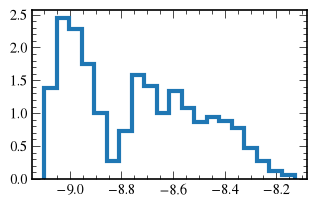

In [35]:
which_loud_source = 0
which_cw_param = 2
plt.hist(selected_holo_data[which_cw_param, :, :].flatten(), **hist_settings)
plt.show()

In [39]:
flow = Flow(data = selected_holo_data.reshape(3, n_p_draws * n_cw).T,
            data_min = jnp.array([False]),
            data_max = jnp.array([False]),
            tset_paths = jnp.array([False]),
            flow_num_layers=4,
            hidden_size=128,
            mlp_num_layers=2,
            num_bins=8,
            learning_rate=1e-4,
            B=6.0,
            p=0.3,
            seed=0)

In [40]:
flow.fit()

Training the flow from pre-loaded data:   0%|          | 0/100 [00:00<?, ?it/s]

In [43]:
samps = flow.sample(num_samples = int(1e5))

In [44]:
samps.shape

(100000, 3)

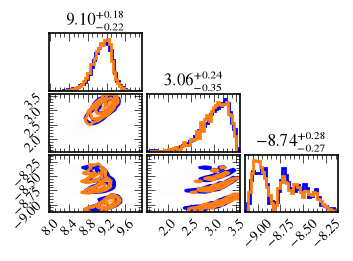

In [46]:
make_corner(chains = [np.array(samps), np.array(selected_holo_data.reshape(3, n_p_draws * n_cw).T)], 
                colors = ['blue', 'C1'], 
               #  labels = [r'$\log_{10}{A_{\rm{GWB}}}$', r'$\gamma$'], 
               #  legend_labels = ['Fixed White Noise (HD)', 'Varied White Noise (HD)'], 
                ranges = None,
                truths = None,
               #  save_path = "/data/taylor_group/Nima/ATLAS/Image/NG15/GWB_under_white_diff.png"
           )

In [ ]:
flow.save_params('flow_params.npz')

# ATLAS

In [3]:
# with open('/data/taylor_group/Nima/Astro/BestCW/psrs_all_inc._low_SNRpkl.pkl', 'rb') as fin:
#     psrs = pickle.load(fin)
# noise_dict = None
# with open('/data/taylor_group/Nima/NG15_v1p1_final_pint_psrs.pkl', 'rb') as fin:
#     psrs = pickle.load(fin)


feather_files = glob.glob('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/*.feather')
psrs = []
for feather_file in feather_files:
    psr = FeatherPulsar.read_feather(feather_file)
    psrs.append(psr)
with open('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

FeatherPulsar.read_feather: cannot find fitpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1937+21.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /data/taylor_group/Nima/15yr_stochasti

In [4]:
data = PTA_Data(psrs, 
                num_gwb_bins = 14,
                num_irn_bins = 30,
                num_det_bins = 60,
                fixed_white_noise_params = None,
                linear_timing = False,
                marg_timing = True,
                diag_white_cov = False,
                
                )

In [5]:
m = ModelBuilder(data = data)
wn = m.make_white_noise(stabilize_TNT = True)
theta0_wn = wn.prior_draw()
theta0_wn = wn.params_dict_to_vector(noise_dict)
theta0_wn[:5]

  0%|          | 0/67 [00:00<?, ?it/s]

Array([ 1.11593531,  1.00004904,  1.04311402,  1.11184323, -7.56416433],      dtype=float64)

In [ ]:
cw_param_mins = np.array([7.2, -8.7, -1., 0, -18., -1., 0., 0.])
cw_param_maxs = np.array([9., -8.2, 1., np.pi, -12., 1., 2. * np.pi, 2. * np.pi])
cw_parameter_bounds = jnp.array([cw_param_mins, cw_param_maxs]).T

psr_dists_measured = jnp.array([psr.pdist[0] for psr in psrs])
psr_dists_std = jnp.array([psr.pdist[1] for psr in psrs])


rn = m.make_red_noise("ltm|unc+cor->unc",
                irn_psd_function = partial(free_spectrum),
                gwb_psd_function = partial(powerlaw),
                orf_function = hd_orf,
                irn_lower_bound_psd = jnp.ones(30) * -9, #jnp.array([-20, 0]),
                irn_upper_bound_psd = jnp.ones(30) * -2, #jnp.array([-11, 7]),
                gwb_lower_bound_psd = jnp.array([-18, 0]),
                gwb_upper_bound_psd = jnp.array([-11, 7]),
                det_delay_function = cw_delay_evolve_float64,
                det_parameter_bounds = cw_parameter_bounds,
                    )

In [8]:
x0 = rn.model.make_initial_guess(jrandom.key(1273442)) #red noise model params
phi0 = rn.model.get_phi_mat_full(x0) #red noise cov matrix
psr_dists0 = jrandom.normal(jrandom.key(234), (data.npsrs,)) * psr_dists_std + psr_dists_measured
psr_phases0 = jrandom.uniform(jrandom.key(992), (data.npsrs,), minval=0., maxval=2.*jnp.pi)
z0 = jrandom.normal(jrandom.key(10098), shape = (rn.npsrs, 60)) # re-parameterized coefficients

cw0 = jrandom.uniform(jrandom.key(123488822), shape=(8,),
                      minval=cw_param_mins, maxval=cw_param_maxs)

cw00 = jrandom.uniform(jrandom.key(1232), shape=(8,),
                      minval=cw_param_mins, maxval=cw_param_maxs)

cw000 = jrandom.uniform(jrandom.key(12322543), shape=(8,),
                      minval=cw_param_mins, maxval=cw_param_maxs)

In [9]:
phi0.shape, x0.shape, z0.shape, cw0.shape, psr_dists0.shape, psr_phases0.shape

((30, 67, 67), (2012,), (67, 60), (8,), (67,), (67,))

In [29]:
raw_res = jnp.concat(data.raw_residuals)
helpers = rn.get_helpers(reff = raw_res, 
                # white_noise_params = None
                white_noise_params = theta0_wn
                )

In [33]:
lnpost, gwb_coeff = rn.lnposterior_reparam( 
                        helpers = helpers,
                        red_params = x0, 
                        z = z0,
                        # D_params = (cw0, psr_phases0, psr_dists0)
)
lnpost

Array(7961467.36609357, dtype=float64)

In [ ]:
def model():

    # reparamed red noise (IRN + GWB) coeff
    z = numpyro.sample('z_red', dist.Normal().expand([rn.npsrs, 28]))

    # deterministic signal parameters
    cw_params = numpyro.sample('cw_params', dist.Uniform(cw_param_mins,
                                                         cw_param_maxs))
    psr_phases = numpyro.sample('psr_phases', dist.Uniform(0., 2. * jnp.pi).expand((data.npsrs,)))
    psr_dists_standard = numpyro.sample('psr_dists_standard', dist.Normal().expand((data.npsrs,)))
    psr_dists = numpyro.deterministic('psr_dists', psr_dists_standard * psr_dists_std + psr_dists_measured)

    # IRN + GWB
    rn_params = numpyro.sample('rn_params', dist.Uniform(rn.model.lower_prior_lim_all, 
                                                         rn.model.upper_prior_lim_all))

    lnpost_val, coeff = rn.lnposterior_reparam_with_det(helpers = helpers, 
                            red_params = rn_params, 
                            z = z,
                            det_params = cw_params,
                            psr_phases = psr_phases,
                            psr_dists = psr_dists)
                            
    # numpyro.deterministic('a', coeff)
    numpyro.factor('lnpost', lnpost_val + 0.5 * jnp.sum(z**2))

In [20]:
nuts_kernel = numpyro.infer.NUTS(model=model, max_tree_depth=12)
mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
                          num_warmup=1000,
                          num_samples=4000,
                          num_chains=1)
mcmc.run(jrandom.key(170817))
samples = mcmc.get_samples()

warmup:   4%|██                                               | 209/5000 [13:07<5:00:59,  3.77s/it, 2047 steps of size 2.93e-03. acc. prob=0.77]


KeyboardInterrupt: 

In [70]:
chain = samples['cw_params']
chain.shape

(4000, 8)

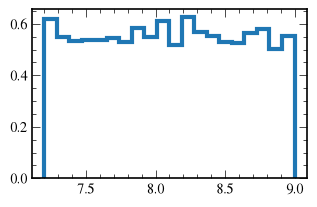

In [71]:
plt.hist(chain[:, 0], **hist_settings)
plt.show()

In [74]:
with open('/data/taylor_group/Nima/Astro/BestCW/NG15_GwbHdPl14_RnFs30_CW.pkl', 'rb') as fin:
    ref = pickle.load(fin)
ref.keys()

dict_keys(['gwb_params', 'psr_params', 'cw_params', 'psr_dists', 'psr_phases'])

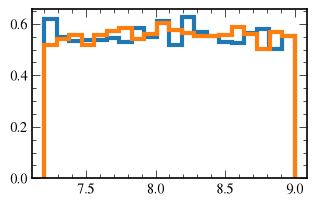

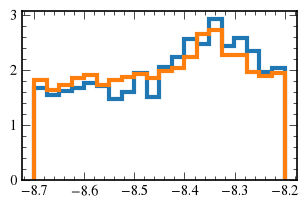

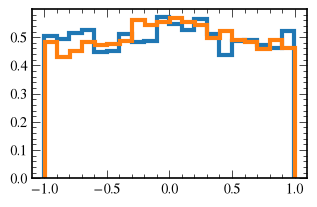

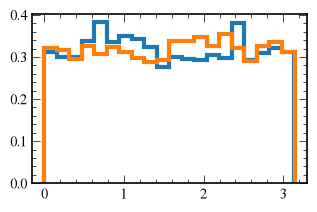

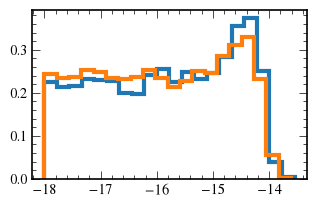

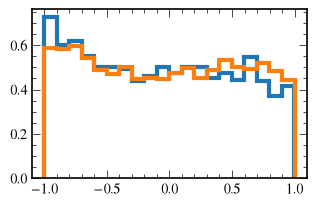

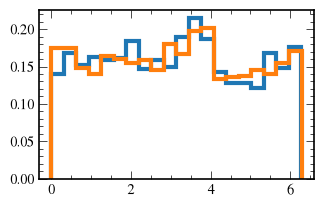

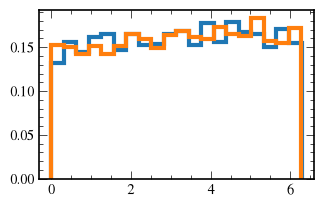

In [75]:
for idx in range(8):
    plt.hist(chain[:, idx], **hist_settings)
    plt.hist(ref['cw_params'][:, idx], **hist_settings)
    plt.show()